# Accès des ménages aux services de base (eau, assainissement, énergie) au Togo

**Auteur :** Bihèbè KAGNIRA — statisticien, Ministère de l'Agriculture, de la Pêche, des Ressources animales et de la Souveraineté alimentaire (Togo)
**Contact :** bihebekagnira@gmail.com
**Date :** mai 2026 (version révisée : octobre 2026)
**Outils :** Python (pandas, matplotlib, seaborn, GeoPandas, statsmodels, scikit-learn)

> Ce notebook se lance depuis le dossier `notebooks/` du projet. Les données brutes ne sont pas diffusées dans le dépôt (voir `README.md`).

## Contexte et objectifs

Ce notebook analyse les conditions d'accès des ménages enquêtés à quatre services de base :

- l'eau de boisson (source principale du ménage) ;
- l'assainissement (type de toilettes) ;
- l'énergie de cuisson ;
- l'éclairage.

**Objectifs :**

1. Construire, pour chaque service, un indicateur binaire fondé sur les normes internationales de suivi des ODD.
2. Synthétiser ces indicateurs dans un indice d'accès aux services de base au niveau du ménage.
3. Décrire et tester les disparités régionales.
4. Mesurer, par une régression logistique, dans quelle mesure la structure du ménage et la région sont associées au niveau d'accès.

## Méthodologie

**Données.** Base `BASE_SAN.sav`, issue d'une enquête ménages sur les conditions d'habitat et l'accès aux services de base (6 749 ménages, 5 régions). Variables utilisées : `HHWaterSRC` (eau), `HHToiletType` (toilettes), `HHEnerCookSRC` (cuisson), `HHEnerLightSRC` (éclairage), `ADMIN1Name` (région), `HHSizeCalc` (taille du ménage), `HHDependentNb` (nombre de dépendants).

**Normes de référence.** Deux cadres distincts sont mobilisés :

| Service | Cadre | Indicateur retenu |
|---|---|---|
| Eau | JMP OMS/UNICEF (ODD 6.1) | Source **améliorée** |
| Assainissement | JMP OMS/UNICEF (ODD 6.2) | Service **de base** : installation améliorée **non partagée** |
| Cuisson | OMS / ODD 7.1.2 | Combustible ou technologie **propre** (électricité, gaz, solaire) |
| Éclairage | ODD 7.1.1 | Accès à l'**électricité** (réseau, mini-réseau, générateur, solaire) |

Le JMP définit le service « de base » pour l'eau comme une source améliorée à moins de 30 minutes aller-retour. La base ne renseignant pas le temps de collecte, l'indicateur « eau » mesure seulement le caractère amélioré de la source.

**Indice.** Somme des quatre indicateurs (0 à 4), ramenée entre 0 et 1, puis classée en trois catégories (faible, moyen, bon).

**Limites connues dès le départ.**
- Les résultats sont **non pondérés** (aucune variable de poids n'est utilisée, voir section 1) : ils décrivent l'échantillon et ne constituent pas des estimations nationales.
- Certaines modalités de la base ne permettent pas de déterminer le type d'installation (par exemple « Latrine privée au ménage ») ; elles sont traitées de façon prudente et testées dans une analyse de sensibilité.

## 1. Chargement et inspection des données

In [24]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 80)

# Le notebook se trouve dans notebooks/ ; la racine du projet est le dossier parent.
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW   = BASE_DIR / "donnees" / "donneesbrutes" / "BASE_SAN.sav"
DATA_OUT   = BASE_DIR / "donnees" / "donneescrees"
SHAPE_FILE = BASE_DIR / "shapes" / "gadm41_TGO_1.json"
OUTPUT_DIR = BASE_DIR / "outputs" / "figures"

DATA_OUT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
if not DATA_RAW.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {DATA_RAW}\n"
        "Placez BASE_SAN.sav dans donnees/donneesbrutes/ (voir README.md)."
    )

df_raw = pd.read_spss(DATA_RAW, convert_categoricals=True)
print(f"{df_raw.shape[0]} ménages, {df_raw.shape[1]} variables")

# Recherche d'une éventuelle variable de pondération
cols_poids = [c for c in df_raw.columns
              if any(m in c.lower() for m in ("weight", "poids", "wgt", "pond"))]
print("Variables de pondération candidates :", cols_poids or "aucune")

6749 ménages, 113 variables
Variables de pondération candidates : aucune


In [26]:
COLS = {
    "ADMIN1Name":     "region",
    "HHSizeCalc":     "taille_menage",
    "HHDependentNb":  "nb_dependants",
    "HHWaterSRC":     "eau",
    "HHToiletType":   "toilette",
    "HHEnerCookSRC":  "cuisson",
    "HHEnerLightSRC": "eclairage",
}

df = df_raw[list(COLS)].rename(columns=COLS).copy()

df["taille_menage"] = pd.to_numeric(df["taille_menage"], errors="coerce")
df["nb_dependants"] = pd.to_numeric(df["nb_dependants"], errors="coerce")
for col in ["region", "eau", "toilette", "cuisson", "eclairage"]:
    df[col] = df[col].astype(str).str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6749 entries, 0 to 6748
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   region         6749 non-null   object 
 1   taille_menage  6749 non-null   int64  
 2   nb_dependants  6550 non-null   float64
 3   eau            6749 non-null   object 
 4   toilette       6749 non-null   object 
 5   cuisson        6749 non-null   object 
 6   eclairage      6749 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 369.2+ KB


### Valeurs manquantes

In [27]:
na = df.isna().sum()
print(pd.DataFrame({"manquants": na, "%": (na / len(df) * 100).round(2)}))

# Les manquants de nb_dependants sont-ils répartis comme l'échantillon ?
tab_na = pd.crosstab(df["region"], df["nb_dependants"].isna())
chi2, p_na, ddl, _ = chi2_contingency(tab_na)

comparaison = pd.DataFrame({
    "% de l'échantillon":  df["region"].value_counts(normalize=True) * 100,
    "% des manquants":     df.loc[df["nb_dependants"].isna(), "region"].value_counts(normalize=True) * 100,
}).round(1)
print(comparaison)
print(f"\nTest du khi-deux (région × manquant) : chi2 = {chi2:.2f}, ddl = {ddl}, p = {p_na:.3f}")

               manquants     %
region                 0  0.00
taille_menage          0  0.00
nb_dependants        199  2.95
eau                    0  0.00
toilette               0  0.00
cuisson                0  0.00
eclairage              0  0.00
          % de l'échantillon  % des manquants
region                                       
Plateaux                31.6             27.1
Kara                    19.7             24.6
Savanes                 18.9             22.6
Maritime                15.2             16.6
Centrale                14.6              9.0

Test du khi-deux (région × manquant) : chi2 = 9.88, ddl = 4, p = 0.042


Les valeurs manquantes ne concernent que le nombre de dépendants (environ 3 % des ménages). Leur répartition régionale s'écarte légèrement de celle de l'échantillon (la région Centrale y est sous-représentée, Kara et les Savanes sur-représentées) ; le test du khi-deux indique que cet écart est significatif au seuil de 5 % (p ≈ 0,04), sans être d'une ampleur préoccupante. Ces ménages sont conservés pour les indicateurs d'accès, qui n'utilisent pas cette variable, et ne sont exclus que de la modélisation (section 5).

### Modalités observées

In [28]:
for col in ["eau", "toilette", "cuisson", "eclairage"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().to_string())


=== eau ===
eau
Puits à pompe/Forage                                                                  2856
Puits creuse protégé                                                                  1047
Robinet public/Borne fontaine                                                          810
Eau de surface (rivière, barrage, lac, mare, courant, canal, système d'irrigation)     736
Puits creuse non-protégé                                                               676
Robinet dans le logement                                                               184
Robinet chez le voisin                                                                 180
Source non-protégé                                                                      93
Robinet dans la concession/jardin/parcelle                                              57
Eau de pluie                                                                            54
Source protégé                                                           

## 2. Construction des indicateurs

Chaque modalité est affectée explicitement à une catégorie. Un contrôle vérifie ensuite qu'aucune modalité observée n'a été oubliée : une modalité non classée signalerait une faute de frappe ou une nouvelle modalité.

**Points de classement à noter :**

- **Eau.** Conformément au JMP (révision 2017), l'eau de pluie, l'eau en sachet et l'eau livrée (camion-citerne, charrette avec citerne) sont des sources **améliorées**.
- **Assainissement.** Les toilettes suspendues, les latrines sans dalle et les latrines à seau sont **non améliorées**. Les installations améliorées mais partagées (« partagée », « communale ») ne relèvent pas du service de base.
- **Modalités ambiguës.** « Latrine privée au ménage » et « Latrine communale » décrivent le partage, pas le type d'installation ; « Autre » et « Ne sais pas » sont indéterminés. Par prudence, ils sont comptés comme non améliorés ; l'effet de ce choix est mesuré plus bas.
- **Cuisson.** Le solaire est un combustible propre selon l'OMS. La modalité « Aucun » (pas de cuisson) est comptée comme non propre, faute d'effectif suffisant pour un traitement à part.
- **Éclairage.** Seules les sources électriques (réseau, électrification rurale, générateur, solaire) sont retenues. La lampe à gaz et la torche à piles ne correspondent pas à l'accès à l'électricité au sens de l'ODD 7.1.1.

In [29]:
CLASSEMENT = {
    "eau": {
        "ameliore": [
            "Puits à pompe/Forage", "Puits creuse protégé", "Source protégé",
            "Robinet dans le logement", "Robinet dans la concession/jardin/parcelle",
            "Robinet chez le voisin", "Robinet public/Borne fontaine", "Kiosque à eau",
            "Eau de pluie", "Eau en sachet", "Camion citerne", "Charrette avec petite citerne",
        ],
        "non_ameliore": [
            "Puits creuse non-protégé", "Source non-protégé",
            "Eau de surface (rivière, barrage, lac, mare, courant, canal, système d'irrigation)",
            "Autre", "Ne sait pas",
        ],
    },
    "toilette": {
        # Installations améliorées selon le JMP (partagées ou non)
        "ameliore": [
            "Toilettes à chasse d'eau", "Toilette à chasse d'eau (propre)",
            "Toilette à chasse d'eau (partagée)", "Chasser-verser dans la fosse",
            "Latrine à fosse en ciment", "Latrine à fosse VIP/simple avec sol/à dalle",
            "Latrine à fosse Blair", "Fosse améliorée ventilée",
            "Fosse améliorée ventilée (Privée au ménage)", "Fosse améliorée ventilée (Communale)",
            "Compostage/latrine sèche",
        ],
        "non_ameliore": [
            "Pas d'installation, de champ, de buisson, de sac en plastique",
            "Latrine à fosse sans sol/dalle", "Toilettes/latrines suspendues",
            "Toilettes de service ou latrines à seau", "Chasser ou verser-chasser ailleur",
            "Latrines à fosse (VIP) non ventilées/améliorées",
        ],
        # Type d'installation indéterminé : traité comme non amélioré (choix prudent)
        "ambigu": [
            "Latrine privée au ménage", "Latrine communale", "Autre (précisez)", "Ne sais pas",
        ],
    },
    "cuisson": {
        "ameliore": ["Gaz", "Électricité", "Énergie solaire"],
        "non_ameliore": [
            "Bois de chauffage (Collecté)", "Bois de chauffage (Acheté)", "Charbon",
            "Paille", "Aucun", "Autre (précisez)",
        ],
    },
    "eclairage": {
        "ameliore": [
            "Fournisseur public d'électricité", "Fournisseur privé d'électricité",
            "Plan d'électrification rurale", "Générateur",
            "Kit d'énergie solaire (plusieurs lampes)", "Lanterne solaire simple",
            "Système solaire domestique complet (suffisant pour plusieurs lampes et appareils électriques)",
        ],
        "non_ameliore": [
            "Torche", "Gaz", "Bougies", "Huile", "Charbon",
            "Feu (bois, paille, etc.)", "Aucun", "Autre (précisez)",
        ],
    },
}

# Installations améliorées mais partagées : exclues du service de base
TOILETTES_PARTAGEES = [
    "Toilette à chasse d'eau (partagée)", "Fosse améliorée ventilée (Communale)",
]

# Contrôle : toute modalité observée doit être classée
for var, groupes in CLASSEMENT.items():
    connues = set().union(*groupes.values())
    oubliees = set(df[var].unique()) - connues
    if oubliees:
        print(f"ATTENTION – modalités non classées pour '{var}' : {sorted(oubliees)}")
    else:
        print(f"'{var}' : toutes les modalités sont classées")

'eau' : toutes les modalités sont classées
'toilette' : toutes les modalités sont classées
'cuisson' : toutes les modalités sont classées
'eclairage' : toutes les modalités sont classées


In [30]:
df["eau_amelioree"]       = df["eau"].isin(CLASSEMENT["eau"]["ameliore"]).astype(int)
df["toilette_amelioree"]  = df["toilette"].isin(CLASSEMENT["toilette"]["ameliore"]).astype(int)
df["toilette_base"]       = (df["toilette_amelioree"].eq(1)
                             & ~df["toilette"].isin(TOILETTES_PARTAGEES)).astype(int)
df["cuisson_propre"]      = df["cuisson"].isin(CLASSEMENT["cuisson"]["ameliore"]).astype(int)
df["eclairage_electrique"] = df["eclairage"].isin(CLASSEMENT["eclairage"]["ameliore"]).astype(int)

INDICATEURS = ["eau_amelioree", "toilette_base", "cuisson_propre", "eclairage_electrique"]
LIBELLES = {
    "eau_amelioree":        "Eau améliorée",
    "toilette_amelioree":   "Assainissement amélioré (partagé ou non)",
    "toilette_base":        "Assainissement de base",
    "cuisson_propre":       "Cuisson propre",
    "eclairage_electrique": "Éclairage électrique",
}

### Taux d'accès dans l'échantillon

Les taux sont accompagnés d'un intervalle de confiance à 95 % (méthode de Wilson). Ces intervalles supposent un échantillonnage aléatoire simple ; avec un plan de sondage stratifié ou en grappes, ils seraient plus larges.

In [31]:
lignes = []
for var in ["eau_amelioree", "toilette_amelioree", "toilette_base", "cuisson_propre", "eclairage_electrique"]:
    n_succes, n = int(df[var].sum()), len(df)
    bas, haut = proportion_confint(n_succes, n, alpha=0.05, method="wilson")
    lignes.append({"Indicateur": LIBELLES[var], "Taux (%)": 100 * n_succes / n,
                   "IC 95 % bas": 100 * bas, "IC 95 % haut": 100 * haut})

taux = pd.DataFrame(lignes).set_index("Indicateur").round(1)
taux

,Taux (%),IC 95 % bas,IC 95 % haut
Indicateur,,,
Eau améliorée,77.6,76.6,78.6
Assainissement amélioré (partagé ou non),33.4,32.3,34.6
Assainissement de base,31.4,30.3,32.5
Cuisson propre,2.4,2.1,2.8
Éclairage électrique,67.8,66.7,68.9


### Sensibilité du classement de l'assainissement

Le taux d'assainissement de base dépend du traitement des modalités ambiguës. Le tableau ci-dessous compare le choix retenu (prudent) avec l'hypothèse où les « latrines privées au ménage » seraient toutes des installations améliorées.

In [32]:
hyp_haute = (df["toilette_base"].eq(1) | df["toilette"].eq("Latrine privée au ménage")).astype(int)

sensibilite = pd.DataFrame({
    "Choix retenu (%)":                   df.groupby("region")["toilette_base"].mean() * 100,
    "Si latrines privées améliorées (%)": hyp_haute.groupby(df["region"]).mean() * 100,
}).round(1)
sensibilite.loc["Ensemble"] = [df["toilette_base"].mean() * 100, hyp_haute.mean() * 100]
sensibilite.round(1)

,Choix retenu (%),Si latrines privées améliorées (%)
region,,
Centrale,33.9,39.5
Kara,24.2,26.0
Maritime,39.9,43.0
Plateaux,28.4,32.0
Savanes,35.2,38.7
Ensemble,31.4,34.8


## 3. Indice global d'accès aux services

L'indice est construit en trois étapes :

1. comptage du nombre de services accessibles par ménage (0 à 4) ;
2. normalisation entre 0 et 1 (`indice_services`) ;
3. classement en trois catégories : **faible** (0 ou 1 service), **moyen** (2 services), **bon** (3 ou 4 services).

Les quatre services ont le même poids. La cuisson propre étant très rare (voir section 2), l'indice repose en pratique sur trois services : un ménage classé « bon » dispose presque toujours de l'eau améliorée, de l'assainissement de base et de l'éclairage électrique à la fois.

In [33]:
df["nb_services"]     = df[INDICATEURS].sum(axis=1)
df["indice_services"] = df["nb_services"] / len(INDICATEURS)
df["cat_acces"] = pd.cut(df["nb_services"], bins=[-1, 1, 2, 4],
                         labels=["Faible", "Moyen", "Bon"], ordered=True)

print("Répartition du nombre de services accessibles :")
print(df["nb_services"].value_counts().sort_index().to_string())
print("\nRépartition par catégorie :")
print(df["cat_acces"].value_counts().sort_index().to_string())
print(f"\nIndice moyen : {df['indice_services'].mean():.3f} (écart-type {df['indice_services'].std():.3f})")

Répartition du nombre de services accessibles :
nb_services
0     556
1    1868
2    2808
3    1454
4      63

Répartition par catégorie :
cat_acces
Faible    2424
Moyen     2808
Bon       1517

Indice moyen : 0.448 (écart-type 0.226)


## 4. Disparités régionales

### 4.1 Indicateurs et indice par région

In [34]:
resume_region = (
    df.groupby("region")[INDICATEURS + ["indice_services"]]
      .mean()
      .assign(effectif=df["region"].value_counts())
      .sort_values("indice_services", ascending=False)
)
resume_region.round(2)

,eau_amelioree,toilette_base,cuisson_propre,eclairage_electrique,indice_services,effectif
region,,,,,,
Centrale,0.85,0.34,0.02,0.77,0.49,985
Maritime,0.70,0.40,0.04,0.74,0.47,1026
Kara,0.93,0.24,0.02,0.68,0.47,1329
Plateaux,0.70,0.28,0.04,0.69,0.43,2132
Savanes,0.76,0.35,0.01,0.53,0.41,1277


In [35]:
tab_cat = pd.crosstab(df["region"], df["cat_acces"])
tab_cat_pct = (tab_cat.div(tab_cat.sum(axis=1), axis=0) * 100).round(1)

chi2, p_cat, ddl, _ = chi2_contingency(tab_cat)
print(f"Test du khi-deux (région × catégorie d'accès) : chi2 = {chi2:.1f}, ddl = {ddl}, p = {p_cat:.2g}\n")
tab_cat_pct

Test du khi-deux (région × catégorie d'accès) : chi2 = 197.2, ddl = 8, p = 2.5e-38



cat_acces,Faible,Moyen,Bon
region,,,
Centrale,23.4,52.6,24.1
Kara,30.1,49.2,20.7
Maritime,33.5,39.3,27.2
Plateaux,40.7,38.0,21.3
Savanes,45.7,33.0,21.3


In [36]:
# Synthèse automatique : région la mieux et la moins bien placée pour chaque indicateur
for var in INDICATEURS + ["indice_services"]:
    serie = resume_region[var]
    nom = LIBELLES.get(var, "Indice global")
    print(f"{nom:<25} max : {serie.idxmax():<9} ({serie.max():.2f})   "
          f"min : {serie.idxmin():<9} ({serie.min():.2f})")

Eau améliorée             max : Kara      (0.93)   min : Maritime  (0.70)
Assainissement de base    max : Maritime  (0.40)   min : Kara      (0.24)
Cuisson propre            max : Maritime  (0.04)   min : Savanes   (0.01)
Éclairage électrique      max : Centrale  (0.77)   min : Savanes   (0.53)
Indice global             max : Centrale  (0.49)   min : Savanes   (0.41)


In [37]:
# Export des tableaux régionaux
with pd.ExcelWriter(DATA_OUT / "resume_region_services_base.xlsx") as writer:
    resume_region.round(3).to_excel(writer, sheet_name="indicateurs_region")
    tab_cat_pct.to_excel(writer, sheet_name="categories_region")
    taux.to_excel(writer, sheet_name="taux_echantillon")
print("Export :", DATA_OUT / "resume_region_services_base.xlsx")

Export : c:\Users\LENOVO\Desktop\Python\Projet_GitHub\donnees\donneescrees\resume_region_services_base.xlsx


**Lecture.** Les écarts régionaux sont nets et le test du khi-deux confirme que la répartition des ménages entre catégories d'accès dépend de la région. L'eau améliorée est l'indicateur le plus répandu, avec un niveau particulièrement élevé à Kara. L'assainissement de base reste minoritaire dans toutes les régions et constitue, avec la cuisson, le principal déficit. La cuisson propre est marginale partout : la quasi-totalité des ménages utilise le bois ou le charbon. L'éclairage électrique est majoritaire, d'abord grâce au réseau (fournisseur public ou privé, électrification rurale), complété par le solaire, mais la région des Savanes est nettement en retrait. Les Savanes et les Plateaux concentrent la plus forte part de ménages en accès faible.

### 4.2 Graphiques

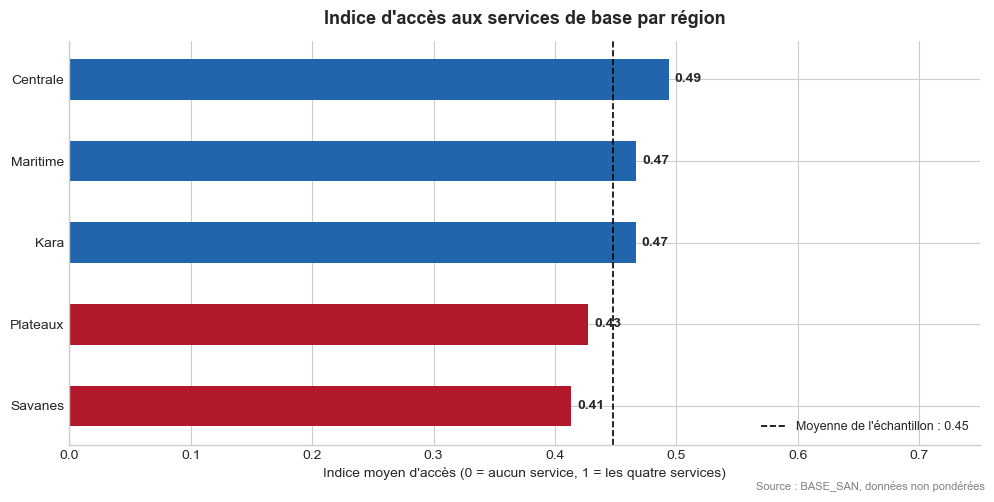

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

donnees = resume_region.sort_values("indice_services")
moyenne = df["indice_services"].mean()
couleurs = ["#2166AC" if v >= moyenne else "#B2182B" for v in donnees["indice_services"]]

barres = ax.barh(donnees.index, donnees["indice_services"], color=couleurs, height=0.5)
for barre, val in zip(barres, donnees["indice_services"]):
    ax.text(barre.get_width() + 0.005, barre.get_y() + barre.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=10, fontweight="bold")

ax.axvline(moyenne, color="black", linestyle="--", linewidth=1.2,
           label=f"Moyenne de l'échantillon : {moyenne:.2f}")
ax.set_xlim(0, 0.75)
ax.set_xlabel("Indice moyen d'accès (0 = aucun service, 1 = les quatre services)")
ax.set_title("Indice d'accès aux services de base par région", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.99, 0.01, "Source : BASE_SAN, données non pondérées", ha="right", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "indice_par_region.png", dpi=300, bbox_inches="tight")
plt.show()

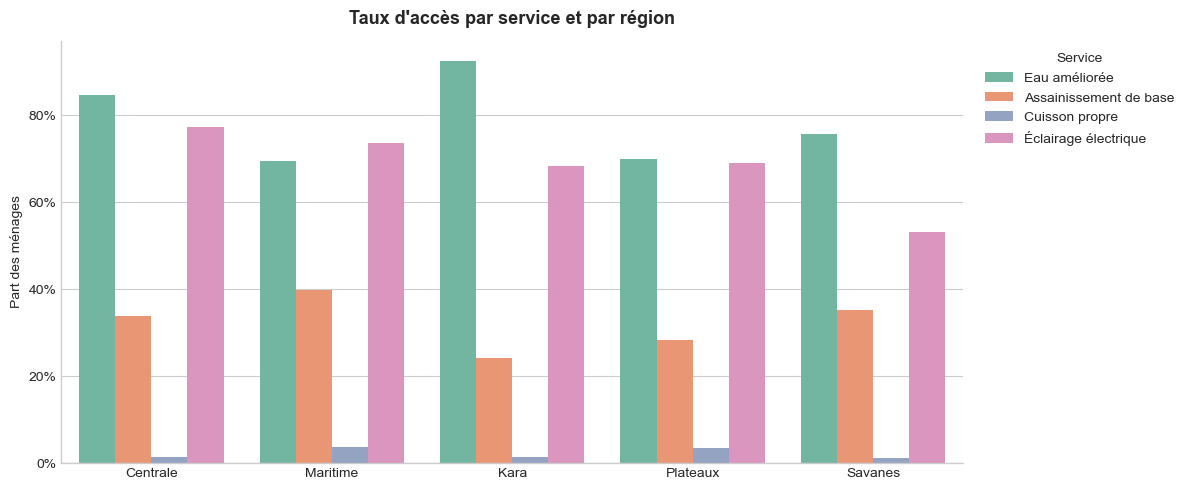

In [39]:
df_long = (resume_region[INDICATEURS]
           .reset_index()
           .melt(id_vars="region", var_name="Indicateur", value_name="Taux"))
df_long["Indicateur"] = df_long["Indicateur"].map(LIBELLES)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_long, x="region", y="Taux", hue="Indicateur", palette="Set2", ax=ax)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Taux d'accès par service et par région", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Part des ménages")
ax.legend(title="Service", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "indicateurs_par_region.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.3 Cartes

Les cartes sont tracées dans une projection métrique (UTM zone 31N, adaptée au Togo), et les étiquettes sont placées dans ce même système de coordonnées.

In [40]:
import geopandas as gpd

regions = gpd.read_file(SHAPE_FILE)
regions["region"] = regions["NAME_1"].replace({"Centre": "Centrale"}).str.strip()

carte = regions.merge(resume_region.reset_index(), on="region", how="left") \
               .merge(tab_cat_pct.reset_index(), on="region", how="left") \
               .to_crs(epsg=32631)

manquantes = carte.loc[carte["indice_services"].isna(), "region"].tolist()
print("Régions sans correspondance :", manquantes or "aucune")

# Point garanti à l'intérieur de chaque polygone, pour les étiquettes
carte["pt_etiquette"] = carte.geometry.representative_point()

import matplotlib.patheffects as pe

def etiqueter(ax, colonne, fmt):
    # Contour blanc autour du texte : lisible sur les régions claires comme foncées
    for _, ligne in carte.iterrows():
        ax.annotate(f"{ligne['region']}\n{format(ligne[colonne], fmt)}",
                    xy=(ligne["pt_etiquette"].x, ligne["pt_etiquette"].y),
                    ha="center", va="center", fontsize=8, fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])

Régions sans correspondance : aucune


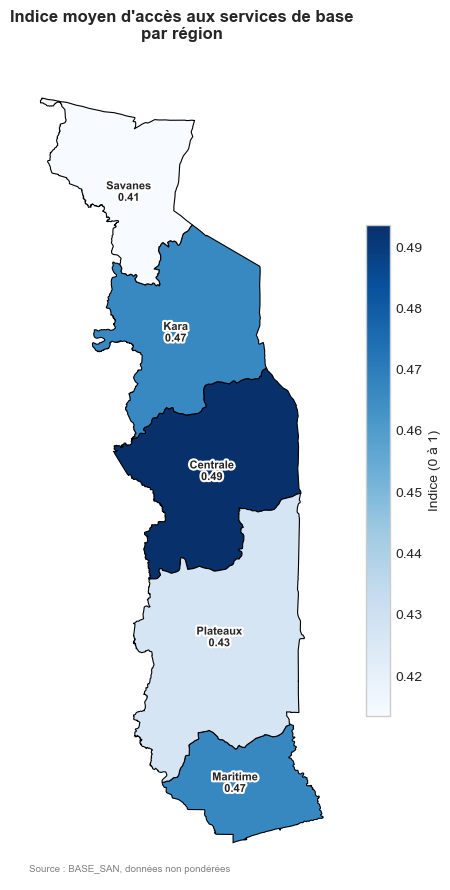

In [41]:
fig, ax = plt.subplots(figsize=(6, 9))
carte.plot(column="indice_services", cmap="Blues", linewidth=0.8, edgecolor="black",
           legend=True, legend_kwds={"label": "Indice (0 à 1)", "shrink": 0.6}, ax=ax)
etiqueter(ax, "indice_services", ".2f")

ax.set_title("Indice moyen d'accès aux services de base\npar région", fontsize=12, fontweight="bold")
ax.text(0.01, 0.01, "Source : BASE_SAN, données non pondérées",
        transform=ax.transAxes, fontsize=7, color="grey")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "carte_indice.png", dpi=300, bbox_inches="tight")
plt.show()

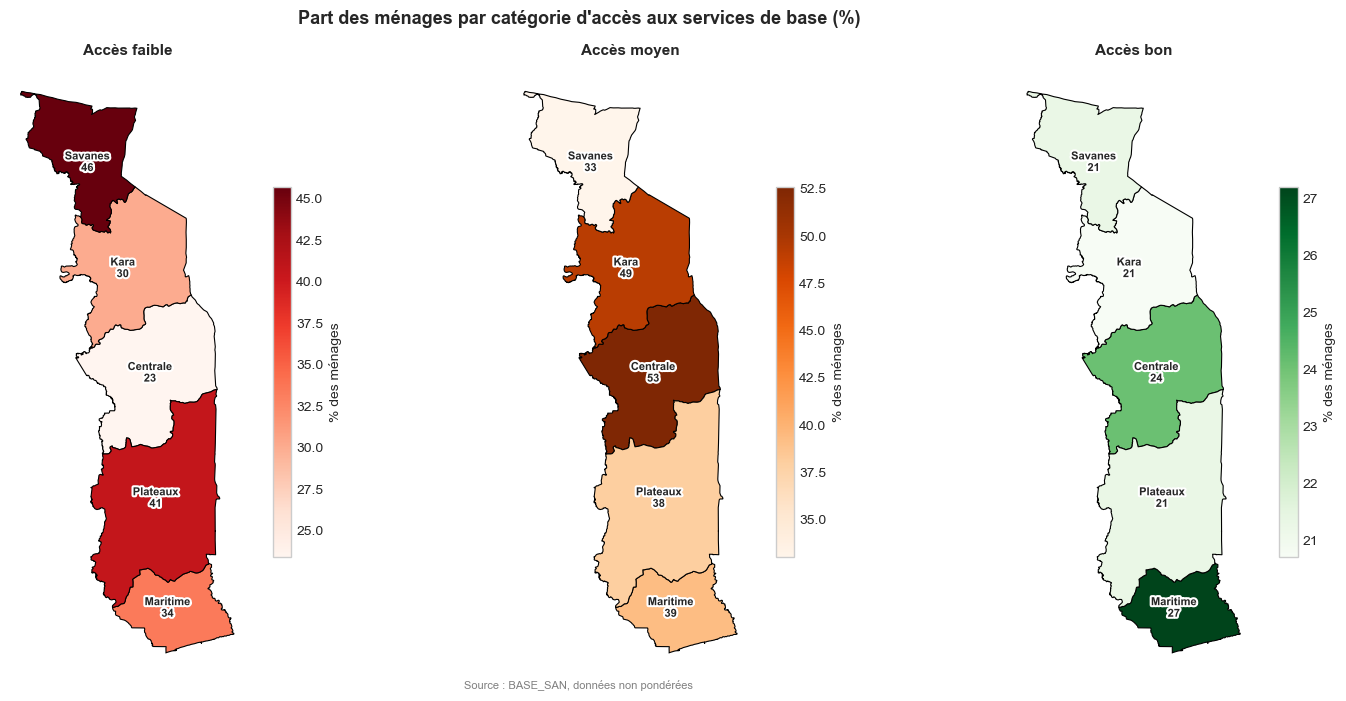

In [42]:
configs = [("Faible", "Reds",    "Accès faible"),
           ("Moyen",  "Oranges", "Accès moyen"),
           ("Bon",    "Greens",  "Accès bon")]

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, (col, cmap, titre) in zip(axes, configs):
    carte.plot(column=col, cmap=cmap, linewidth=0.8, edgecolor="black", legend=True,
               legend_kwds={"shrink": 0.6, "label": "% des ménages"}, ax=ax)
    etiqueter(ax, col, ".0f")
    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle("Part des ménages par catégorie d'accès aux services de base (%)",
             fontsize=13, fontweight="bold")
fig.text(0.5, 0.01, "Source : BASE_SAN, données non pondérées", ha="center", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cartes_categories.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Facteurs associés à l'accès aux services de base

La question posée est **explicative** : quelles caractéristiques sont associées à un accès au moins moyen ? Une régression logistique estimée avec `statsmodels` est donc utilisée ; elle fournit les rapports de cotes, leurs intervalles de confiance et les p-values. Une validation croisée vient ensuite mesurer le pouvoir discriminant du modèle.

- **Variable expliquée :** `acces_ok` = 1 si la catégorie d'accès est « moyen » ou « bon », 0 si elle est « faible ».
- **Variables explicatives :** taille du ménage, nombre de dépendants, région (référence : Centrale).

Les variables ne sont pas standardisées, afin que les rapports de cotes s'interprètent directement (effet d'une personne de plus, ou d'appartenir à une région plutôt qu'à la Centrale).

In [43]:
df["acces_ok"] = (df["cat_acces"] != "Faible").astype(int)

df_model = df[["acces_ok", "taille_menage", "nb_dependants", "region"]].dropna()
print(f"Ménages retenus : {len(df_model)} (exclus pour valeur manquante : {len(df) - len(df_model)})")
print("Répartition de la variable expliquée (%) :")
print((df_model["acces_ok"].value_counts(normalize=True) * 100).round(1).to_string())

# Les deux variables de structure sont-elles redondantes ?
r = df_model["taille_menage"].corr(df_model["nb_dependants"])
print(f"\nCorrélation taille du ménage / nombre de dépendants : r = {r:.2f}")

Ménages retenus : 6550 (exclus pour valeur manquante : 199)
Répartition de la variable expliquée (%) :
acces_ok
1    63.9
0    36.1

Corrélation taille du ménage / nombre de dépendants : r = 0.06


In [44]:
import statsmodels.formula.api as smf

logit = smf.logit(
    "acces_ok ~ taille_menage + nb_dependants + C(region, Treatment('Centrale'))",
    data=df_model,
).fit(disp=False)

resultats = pd.DataFrame({
    "Rapport de cotes": np.exp(logit.params),
    "IC 95 % bas":      np.exp(logit.conf_int()[0]),
    "IC 95 % haut":     np.exp(logit.conf_int()[1]),
    "p-value":          logit.pvalues,
}).drop(index="Intercept")
resultats.index = (resultats.index
                   .str.replace(r"C\(region, Treatment\('Centrale'\)\)\[T\.", "Région : ", regex=True)
                   .str.replace("]", "", regex=False))

print(f"Pseudo-R² de McFadden : {logit.prsquared:.3f}")
resultats.round(3)

Pseudo-R² de McFadden : 0.025


,Rapport de cotes,IC 95 % bas,IC 95 % haut,p-value
Région : Kara,0.724,0.598,0.878,0.001
Région : Maritime,0.648,0.530,0.792,0.000
Région : Plateaux,0.465,0.390,0.553,0.000
Région : Savanes,0.354,0.293,0.427,0.000
taille_menage,1.023,1.008,1.039,0.004
nb_dependants,1.079,1.041,1.117,0.000


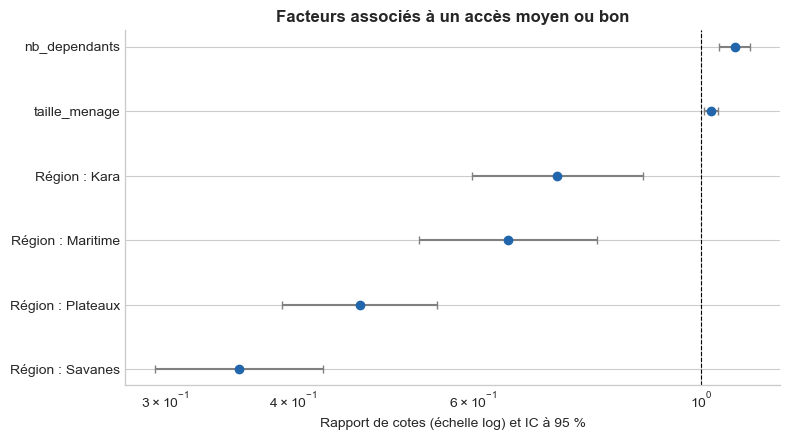

In [45]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ordre = resultats.sort_values("Rapport de cotes")
y = np.arange(len(ordre))

ax.errorbar(ordre["Rapport de cotes"], y,
            xerr=[ordre["Rapport de cotes"] - ordre["IC 95 % bas"],
                  ordre["IC 95 % haut"] - ordre["Rapport de cotes"]],
            fmt="o", color="#2166AC", ecolor="grey", capsize=3)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y, ordre.index)
ax.set_xscale("log")
ax.set_xlabel("Rapport de cotes (échelle log) et IC à 95 %")
ax.set_title("Facteurs associés à un accès moyen ou bon", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rapports_de_cotes.png", dpi=300, bbox_inches="tight")
plt.show()

### Pouvoir discriminant (validation croisée)

L'AUC est estimée par validation croisée stratifiée en 5 blocs, ce qui est plus stable qu'un découpage unique entraînement/test. La pondération `class_weight="balanced"` compense le déséquilibre entre les deux classes.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = pd.get_dummies(df_model[["taille_menage", "nb_dependants", "region"]],
                   columns=["region"], drop_first=True, dtype=int)
y = df_model["acces_ok"]

pipeline = make_pipeline(StandardScaler(),
                         LogisticRegression(class_weight="balanced", max_iter=1000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")

print(f"AUC en validation croisée : {auc.mean():.3f} (écart-type {auc.std():.3f})")

AUC en validation croisée : 0.603 (écart-type 0.023)


### Interprétation

- **Pouvoir explicatif.** Le pseudo-R² et l'AUC mesurent la capacité du modèle à distinguer les ménages en accès faible des autres. Une AUC proche de 0,6 indique un pouvoir discriminant faible : la structure du ménage et la région n'expliquent qu'une petite partie des différences d'accès.
- **Région.** Un rapport de cotes inférieur à 1 signifie que, à structure de ménage égale, les ménages de la région ont moins de chances que ceux de la Centrale d'avoir un accès au moins moyen. Seuls les rapports dont l'intervalle de confiance exclut 1 sont interprétés comme des écarts significatifs. Ici, les quatre régions sont significativement en retrait par rapport à la Centrale, les Savanes le plus nettement, suivies des Plateaux.
- **Structure du ménage.** La taille du ménage et le nombre de dépendants sont très peu corrélés (voir le coefficient r affiché plus haut) : leurs effets peuvent donc être lus séparément. Les deux rapports de cotes sont légèrement supérieurs à 1 : à région égale, les ménages plus grands ou comptant plus de dépendants ont un peu plus de chances d'avoir un accès au moins moyen. Cette association est modeste et ne prouve aucun lien de causalité : elle peut refléter des caractéristiques non observées des ménages (milieu de résidence, revenu, statut d'occupation du logement).

## 6. Limites

- **Pondération et plan de sondage.** Les résultats sont non pondérés et les intervalles de confiance ignorent la stratification et le tirage en grappes. Ils décrivent l'échantillon, pas l'ensemble des ménages togolais.
- **Normes partiellement applicables.** Le temps de collecte de l'eau et le mode de vidange des latrines ne sont pas disponibles : l'indicateur « eau » mesure une source améliorée et non le service de base complet.
- **Modalités ambiguës.** Le classement prudent des latrines de type indéterminé tire le taux d'assainissement vers le bas ; l'analyse de sensibilité (section 2) en donne l'ampleur.
- **Variables explicatives limitées.** Le revenu, le niveau d'instruction, le milieu (urbain/rural) et la distance aux infrastructures ne figurent pas dans le modèle, alors qu'ils sont probablement des déterminants majeurs de l'accès.

## 7. Conclusion

L'analyse met en évidence des écarts régionaux significatifs d'accès aux services de base. L'eau améliorée est largement répandue, tandis que l'assainissement de base et surtout la cuisson propre restent des déficits majeurs dans toutes les régions. L'éclairage électrique, assuré surtout par le réseau et complété par le solaire, est majoritaire mais nettement moins diffusé dans les Savanes. Une part importante des ménages cumule plusieurs privations, ce qui justifie un ciblage des régions les plus défavorisées, en particulier les Savanes et les Plateaux. Enfin, la structure du ménage et la région expliquent mal les niveaux d'accès : l'intégration de variables socio-économiques et d'informations sur les infrastructures, ainsi que la prise en compte des pondérations de l'enquête, constituent les prolongements naturels de ce travail.